# 08. Secondary dataset: the full framework on Credit Card Fraud

This notebook runs the same src modules on a second dataset, the ULB Credit Card Fraud data, to test whether the framework generalises. Credit Card has real fraud labels (Class), so Module 1 is evaluated against genuine anomalies with no injection. Modules 2 and 3, the integration layer, and the ablation are driven by a Credit Card column config and call the identical parameterised src functions used for IBM.

One limitation to state in the methodology: V1 to V28 are anonymised PCA components, so Module 2's structural and categorical checks are not business-meaningful here. Only the statistical (KS) check and the Random Forest drift classifier are used, and there are no categorical columns.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import module1_anomaly as m1
import module1_autoencoder as ae
import module2_drift as m2
import module3_missing as m3
import integration as ig
import ablation as ab
DATA_PATH = '../data/creditcard.csv'
vcols = [f'V{i}' for i in range(1,29)]

In [2]:
df = pd.read_csv(DATA_PATH)
df['log_amount'] = np.log1p(df['Amount'].clip(lower=0))
feat_cols = vcols + ['log_amount']

# Credit Card schema config: the SAME src framework, driven by these column roles.
CC = dict(
    amount_col='Amount',
    m2_numeric=['Amount'] + vcols[:6],   # KS on Amount + first 6 PCA comps
    m2_categorical=[],                   # no categoricals -> KS only
    drift_col='Amount',
    m3_feature_kwargs=dict(log_cols=['Amount'], passthrough_cols=vcols,
                           categorical_cols=[], time_col=None),
    abl_cols=dict(amount='Amount', drift='Amount', missing='V1',
                  drift_numeric=['Amount']+vcols[:6], drift_categorical=[]),
)
print('shape:', df.shape, '| fraud rate: %.3f%%' % (100*df.Class.mean()))

shape: (284807, 32) | fraud rate: 0.173%


## EDA and preprocessing: Credit Card

rows: 284807 | columns: 32
fraud (Class=1): 492  (0.173%)
missing values in file: 0
Amount  min 0.00  median 22.00  max 25691.16  skew 17.0


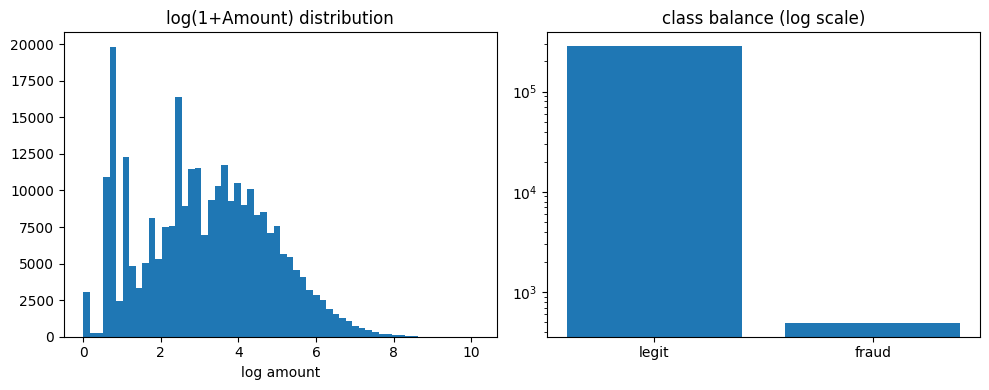

In [3]:
print('rows: %d | columns: %d' % (df.shape[0], df.shape[1]))
print('fraud (Class=1): %d  (%.3f%%)' % (int(df.Class.sum()), 100*df.Class.mean()))
print('missing values in file:', int(df.isna().sum().sum()))
print('Amount  min %.2f  median %.2f  max %.2f  skew %.1f'
      % (df.Amount.min(), df.Amount.median(), df.Amount.max(), df.Amount.skew()))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(df['log_amount'], bins=60); ax[0].set_title('log(1+Amount) distribution'); ax[0].set_xlabel('log amount')
ax[1].bar(['legit', 'fraud'], [(df.Class==0).sum(), (df.Class==1).sum()])
ax[1].set_yscale('log'); ax[1].set_title('class balance (log scale)')
plt.tight_layout(); plt.savefig('../results/secondary_eda.png', dpi=120); plt.show()

## Module 1: anomaly detection against real fraud labels
Fit detectors on legitimate transactions (the clean reference), score all of them, and evaluate against `Class`.

In [4]:
legit = df[df.Class==0]
scaler = StandardScaler().fit(legit[feat_cols].values)
X = scaler.transform(df[feat_cols].values)
Xref = scaler.transform(legit.sample(50_000, random_state=42)[feat_cols].values)
y = df['Class'].values
iso = m1.fit_isolation_forest(Xref); s_iso = m1.score_isolation_forest(iso, X)
lof = m1.fit_lof(Xref);             s_lof = m1.score_lof(lof, X)
sz, _ = m1.zscore_scores(X[:,-1], ref_values=Xref[:,-1])
autoenc = ae.train_autoencoder(Xref, epochs=20)   # autoencoder on the 29 features
s_ae = ae.score_autoencoder(autoenc, X)
scores = {'Isolation Forest': s_iso, 'LOF': s_lof, 'Z-score (amount)': sz, 'Autoencoder': s_ae}
rows = [[nm, round(roc_auc_score(y,s),3), round(average_precision_score(y,s),3)] for nm,s in scores.items()]
pd.DataFrame(rows, columns=['detector','ROC-AUC','PR-AUC'])

,detector,ROC-AUC,PR-AUC
0,Isolation Forest,0.953,0.132
1,LOF,0.956,0.356
2,Z-score (amount),0.705,0.004
3,Autoencoder,0.956,0.521


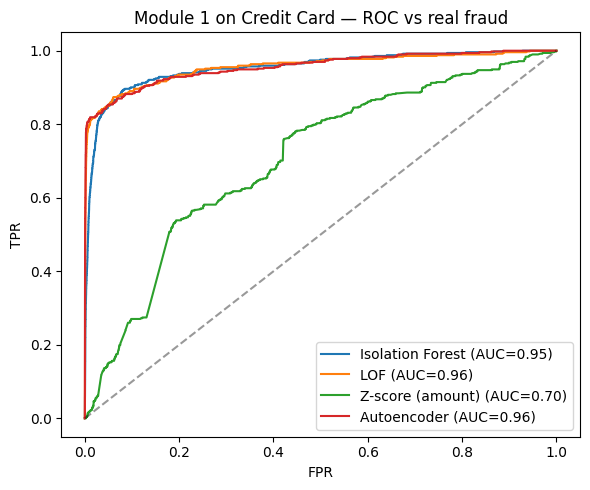

In [5]:
plt.figure(figsize=(6,5))
for nm,s in scores.items():
    fpr,tpr,_=roc_curve(y,s); plt.plot(fpr,tpr,label=f'{nm} (AUC={roc_auc_score(y,s):.2f})')
plt.plot([0,1],[0,1],'k--',alpha=0.4); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Module 1 on Credit Card — ROC vs real fraud'); plt.legend()
plt.tight_layout(); plt.savefig('../results/secondary_module1_roc.png', dpi=120); plt.show()

## Module 2: drift via the framework (`module2_drift`)
Statistical KS check and Random Forest drift classifier. Structural and categorical checks are omitted because the columns are anonymised PCA components.

In [6]:
# (a) statistical check: does the distribution shift between the first and second halves of time?
half = df.Time.median(); first = df[df.Time<half]; second = df[df.Time>=half]
stat = m2.statistical_check(first, second, CC['m2_numeric'], CC['m2_categorical'])
pd.DataFrame([{'column':k, 'ks_stat':round(v['ks_stat'],3), 'p_value':format(v['p_value'],'.1e'),
               'drifted':v['drifted']} for k,v in stat.items()])

,column,ks_stat,p_value,drifted
0,Amount,0.024,4.9e-35,True
1,V1,0.416,0.0e+00,True
2,V2,0.039,4.0e-94,True
3,V3,0.511,0.0e+00,True
4,V4,0.171,0.0e+00,True
5,V5,0.265,0.0e+00,True
6,V6,0.114,0.0e+00,True


In [7]:
# (b) RF drift classifier: trained on injected shift over the reference period, evaluated at held-out rates
legit_sorted = df[df.Class==0].sort_values('Time').reset_index(drop=True)
ref_period = legit_sorted.iloc[:len(legit_sorted)//2].reset_index(drop=True)
ref_batch  = ref_period.sample(20_000, random_state=42).reset_index(drop=True)
Xtr,ytr = m2.build_drift_dataset(ref_batch, ref_period, rates=[0.05,0.10], batch_size=5000,
            n_per_rate=20, numeric_cols=CC['m2_numeric'], categorical_cols=CC['m2_categorical'],
            drift_col=CC['drift_col'], seed=42)
drift_clf = m2.train_drift_classifier(Xtr, ytr)
Xte,yte = m2.build_drift_dataset(ref_batch, ref_period, rates=[0.20,0.30], batch_size=5000,
            n_per_rate=20, numeric_cols=CC['m2_numeric'], categorical_cols=CC['m2_categorical'],
            drift_col=CC['drift_col'], seed=99)
ev = m2.evaluate_drift_classifier(drift_clf, Xte, yte)
print('Module 2 drift classifier (held-out rates 20%%/30%%): ROC-AUC %.3f  F1 %.3f' % (ev['roc_auc'], ev['f1']))

Module 2 drift classifier (held-out rates 20%/30%): ROC-AUC 1.000  F1 1.000


## Module 3: missing-value prediction via the framework (`module3_missing`)
MAR missingness injected on `Amount`, predicted from `V1` to `V28`.

In [8]:
train = df.sample(80_000, random_state=42).reset_index(drop=True)
test  = df.sample(40_000, random_state=7).reset_index(drop=True)
res_mar = m3.run_module3(train, test, ['Amount'], mechanism='mar', rate=0.10,
                         driver='Amount', feature_kwargs=CC['m3_feature_kwargs'])
print('Module 3 MAR (predict Amount-missing from V1-V28): ROC-AUC %.3f' % res_mar['Amount']['roc_auc'])

Module 3 MAR (predict Amount-missing from V1-V28): ROC-AUC 0.722


## Integration: `DQFramework` end-to-end on Credit Card
Assemble the three fitted modules and assess a clean batch against a corrupted batch.

In [9]:
ref = df[df.Class==0].sample(50_000, random_state=42).reset_index(drop=True)
logamt = np.log1p(ref['Amount'].clip(lower=0))
mc, mg = m3.inject_missing_values_mar(ref, 'Amount', rate=0.10, driver='Amount', seed=1)
Xm = m3.build_module3_features(mc, 'Amount', **CC['m3_feature_kwargs'])
miss_clf = m3.train_missing_classifier(Xm, mg.values)
fitted = {
    'ref_log_mean': float(logamt.mean()), 'ref_log_std': float(logamt.std()),
    'drift_clf': drift_clf,
    'drift_feature_fn': (lambda r,b: m2.drift_feature_vector(r,b, CC['m2_numeric'], CC['m2_categorical'])),
    'missing_clf': miss_clf,
    'missing_feature_fn': (lambda b,t: m3.build_module3_features(b,t, **CC['m3_feature_kwargs'])),
    'missing_target':'Amount', 'missing_columns': list(Xm.columns),
}
fw = ig.DQFramework(ref, fitted, mode='general', amount_col='Amount')
clean = df[df.Class==0].sample(20_000, random_state=5).reset_index(drop=True)
bad   = ab.corrupt_batch(clean, 'anomaly', seed=1, cols=CC['abl_cols'])
rep_clean = fw.assess(clean); rep_bad = fw.assess(bad)
print('clean batch: combined=%.3f  decision=%s  scores=%s'
      % (rep_clean['combined_score'], rep_clean['decision'], {k:round(v,3) for k,v in rep_clean['module_scores'].items()}))
print('bad   batch: combined=%.3f  decision=%s  scores=%s'
      % (rep_bad['combined_score'], rep_bad['decision'], {k:round(v,3) for k,v in rep_bad['module_scores'].items()}))

clean batch: combined=0.107  decision=PASS  scores={'anomaly': 0.001, 'drift': 0.105, 'missing': 0.369}
bad   batch: combined=0.556  decision=FAIL  scores={'anomaly': 0.021, 'drift': 0.94, 'missing': 0.369}


## Ablation on Credit Card: module contribution and weighting schemes
The same `ablation` code as IBM, driven by the Credit Card column config.

                  experiment       f1  accuracy
     A0 Full framework (max) 1.000000  1.000000
A1 Remove Module 1 (anomaly) 1.000000  1.000000
  A2 Remove Module 2 (drift) 0.800000  0.750000
A3 Remove Module 3 (missing) 0.800000  0.750000
         A4 Weighting: equal 0.500000  0.500000
      A4 Weighting: severity 0.593750  0.566667
      A4 Weighting: adaptive 0.571429  0.550000
           A4 Weighting: max 1.000000  1.000000


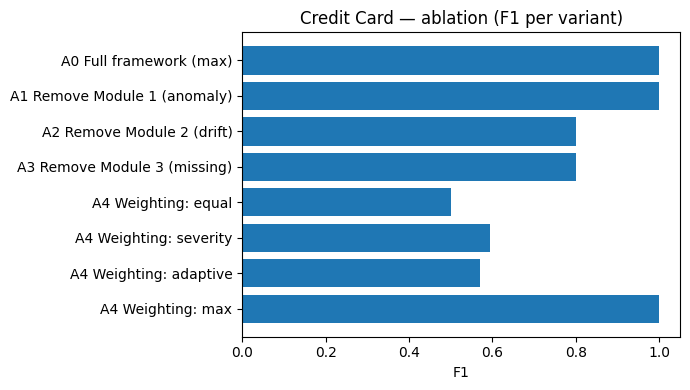

In [10]:
ref_pool = df[df.Class==0]
labelled = ab.build_labelled_scores(ref, ref_pool, fitted, n_each=15, seed=42,
                                    cols=CC['abl_cols'], batch_size=20_000)
tab = ab.run_ablation(labelled, decision_scheme='max')
print(tab.to_string(index=False))
plt.figure(figsize=(7,4)); plt.barh(tab['experiment'], tab['f1'])
plt.xlabel('F1'); plt.title('Credit Card — ablation (F1 per variant)')
plt.gca().invert_yaxis(); plt.tight_layout()
plt.savefig('../results/secondary_ablation.png', dpi=120); plt.show()

## Results

Module 1 detects real fraud at a ROC-AUC of about 0.95 (Isolation Forest, LOF, and the autoencoder), and the autoencoder's PR-AUC is the strongest on this imbalanced set. LOF works here even though it failed on IBM. The reason is that IBM anomalies are global amount-extremes, which is LOF's weak point, whereas Credit Card fraud sits in the multi-dimensional PCA space where LOF's local density estimate is strong. The same framework code runs end-to-end on both datasets (Modules 1 to 3, integration, and ablation), driven only by a column config, which is evidence that the framework generalises rather than just the IBM analysis. The limitation is that V1 to V28 are anonymised, so Module 2's structural and categorical checks and any business-level interpretation do not apply here; the statistical check and drift classifier still do.